# 02 · Online Softmax

> 本实验从数值稳定的 Safe Softmax 出发，推导可以**单趟增量更新**的 Online Softmax 算法。


**目录**
1. [为什么需要 Online Softmax？](#1-为什么需要-Online-Softmax)
2. [Safe Softmax](#2-Safe-Softmax)
3. [Online Softmax 推导](#3-Online-Softmax-推导)
4. [带输出累积的 Online Attention](#4-带输出累积的-Online-Attention)
5. [分块 Online Attention](#5-分块-Online-Attention)
6. [数值精度分析](#6-数值精度分析)
7. [性能对比](#7-性能对比)
8. [小结与展望](#8-小结与展望)

---

## 1 为什么需要 Online Softmax？

在上一篇笔记中，得出的核心结论是：

| 问题 | 根因 |
|------|------|
| 标准注意力显存 $O(N^2)$ | $N\times N$ 注意力矩阵 $A$ 必须完整写入 HBM |
| HBM 带宽瓶颈 | 写 $S$、读 $S$ 做 softmax、写 $A$、读 $A$ 做加权求和——四次 $N^2$ 级 HBM 访问 |

如果能将 $Q$、$K$、$V$ 切成小块，在 SRAM 内完成计算，就不必把 $S$、$A$ 写到 HBM。  
但这里有一个障碍：

> **Softmax 需要全局信息。**  
> $\text{softmax}(x)_i = e^{x_i} / \sum_j e^{x_j}$，分母 $\sum_j e^{x_j}$ 必须遍历整行才能算出来。

如果只看到这一行的一个小块，就无法归一化。
于是引出了 Online Softmax：用两个可增量维护的累积量，在只扫描一遍数据的前提下，得到正确的 softmax 结果。

```
标准流程（两趟扫描）
  第一趟：读整行 → 求全局 max m，求全局 sum ℓ
  第二趟：读整行 → 除以 ℓ·exp(-m) 归一化

Online 流程（一趟扫描）
  逐块读入 → 边读边更新 (m, ℓ)，同时修正已累积的输出 O
  扫描结束时 O 已是正确的注意力输出，无需第二趟
```

In [30]:
import torch
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json
import os

matplotlib.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]
os.makedirs("../results", exist_ok=True)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
device = "cuda"if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2 Safe Softmax

### 2.1 朴素 Softmax 的数值问题

朴素公式 $\text{softmax}(x)_i = e^{x_i} / \sum_j e^{x_j}$ 在 $x_i$ 较大时会溢出（`inf`），较小时下溢（`0`）。

例如 FP32 的上限约 $3.4 \times 10^{38}$，而 $e^{89} \approx 4.5 \times 10^{38}$ 已经溢出。

### 2.2 减去最大值（Safe Softmax）

$$
\text{softmax}(x)_i 
= \frac{e^{x_i - m}}{\sum_j e^{x_j - m}}, \quad m = \max_j x_j
$$

减去 $m$ 后最大指数变为 $0$，所有 $e^{x_i - m} \in (0, 1]$，不会溢出。

同时提取出max后，小项可能下溢，但它们对 Softmax 本身也已经几乎没有贡献

In [31]:
def naive_softmax(x: torch.Tensor) -> torch.Tensor:
    """朴素 softmax，不做处理。"""
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum(dim=-1, keepdim=True)


def safe_softmax(x: torch.Tensor) -> torch.Tensor:
    """Safe softmax：减去行最大值后再计算。"""
    m = x.max(dim=-1, keepdim=True).values
    exp_x = torch.exp(x - m)
    return exp_x / exp_x.sum(dim=-1, keepdim=True)


# ---- 数值问题演示 ----
torch.manual_seed(0)
# 正常值
x_normal = torch.randn(8)
# 大值（会导致朴素版本溢出）
x_large = torch.tensor([100.0, 101.0, 99.0, 102.0, 98.0, 103.0, 97.0, 100.5])

print("=== 正常输入 ===")
ref = torch.softmax(x_normal, dim=-1)
naive = naive_softmax(x_normal)
safe = safe_softmax(x_normal)
print(f"safe 最大误差: {(safe - ref).abs().max():.2e}")

print("\n=== 大值输入 ===")
ref2 = torch.softmax(x_large, dim=-1)
naive2 = naive_softmax(x_large)
safe2 = safe_softmax(x_large)
print(f"naive 输出: {naive2.tolist()}")
print(f"safe 最大误差: {(safe2 - ref2).abs().max():.2e}")

=== 正常输入 ===
safe 最大误差: 1.49e-08

=== 大值输入 ===
naive 输出: [nan, nan, nan, nan, nan, nan, nan, nan]
safe 最大误差: 1.49e-08


可以看出naive 输出有溢出（全是nan）

### 2.3 Safe Softmax 仍是两趟扫描

Safe Softmax 需要：
1. **第一趟**：找全局最大值 $m$
2. **第二趟**：计算 $\sum_j e^{x_j - m}$，再归一化

在分块计算时，「第一趟」意味着要把整行数据读一遍才能开始计算，这与 Tiling 的目标——**一次顺序读取即完成计算**——相冲突。

## 3 Online Softmax 推导

### 3.1 状态变量的定义

设我们已经扫描了 $x_1, x_2, \ldots, x_t$，维护两个**累积量**：

$$
m^{(t)} = \max_{j \le t} x_j \quad\text{（当前已见到的最大值）}
$$
$$
\ell^{(t)} = \sum_{j=1}^{t} e^{x_j - m^{(t)}} \quad\text{（以当前最大值为基准的归一化分母）}
$$

扫描完成后（$t = N$），$m^{(N)}$ 和 $\ell^{(N)}$ 就是全局最大值和分母，无需再读一遍数据。

### 3.2 递推公式推导

当读入第 $t+1$ 个元素 $x_{t+1}$ 时，需要更新 $m$ 和 $\ell$：

**更新 $m$**：
$$
m^{(t+1)} = \max(m^{(t)},\; x_{t+1})
$$

**更新 $\ell$**：旧的 $\ell^{(t)}$ 是以 $m^{(t)}$ 为基准算出的，新基准变成了 $m^{(t+1)}$，需要**修正旧累积量**：
$$
\ell^{(t+1)} = \underbrace{e^{m^{(t)} - m^{(t+1)}} \cdot \ell^{(t)}}_{\text{修正旧项}} + \underbrace{e^{x_{t+1} - m^{(t+1)}}}_{\text{新项}}
$$

In [32]:
def online_softmax_scalar(x: torch.Tensor) -> torch.Tensor:
    """
    依照递推公式，逐元素（标量）Online Softmax
    x: (N,) 一维张量
    返回 softmax(x)
    """
    N = x.shape[0]
    m = float("-inf")   # m^(0)
    l = 0.0   # ℓ^(0)

   # 第一趟：一次扫描，得到全局 m 和 ℓ
    for i in range(N):
        xi = x[i].item()
        m_new = max(m, xi)
        l = math.exp(m - m_new) * l + math.exp(xi - m_new)
        m = m_new

   # 现在 m = 全局最大，l = 全局归一化分母（以 m 为基准）
   # 一次性归一化（无需再扫描一遍，因为分子 e^{x_i - m} 可随时计算）
    return torch.exp(x - m) / l


# ---- 验证 ----
torch.manual_seed(42)
x_test = torch.randn(32)

ref_out = torch.softmax(x_test, dim=0)
online_out = online_softmax_scalar(x_test)

max_err = (ref_out - online_out).abs().max().item()
print(f"Online Softmax（标量）最大误差 vs torch.softmax: {max_err:.2e}")

# 验证大值输入的稳定性
x_large2 = x_test * 50  # 放大，触发朴素版本溢出
ref_large = torch.softmax(x_large2, dim=0)
online_large = online_softmax_scalar(x_large2)
max_err2 = (ref_large - online_large).abs().max().item()
print(f"大值输入最大误差: {max_err2:.2e}")

Online Softmax（标量）最大误差 vs torch.softmax: 1.49e-08
大值输入最大误差: 1.19e-07


可以看出无论是普通值还是大值，都没有触发溢出，且与标准值（torch.softmax）的误差保持在 1e-6 以下

### 3.3 向量化版本（块级递推）

实际应用中，数据以**块**为单位读入，而不是逐个元素。于是沿着被分块遍历的那个维度，对每个块分别维护一组 $m,\ell$，然后把块的结果递推合并

设每块大小为 $B_c$，将 $m$、$\ell$ 的更新从标量推广到块级：

设当前块 $j$ 的 logits 为 $x_{B_c}$，局部最大值和局部分母为：
$$
\tilde{m}_j = \max(x_{B_c}), \quad
\tilde{\ell}_j = \sum_{k \in B_c} e^{x_k - \tilde{m}_j}
$$

全局累积量的更新与标量版本完全对称，只是 $m^{(t)}$ 和 $\tilde{m}_j$ 之间做 `max` 合并，$\ell$ 做加权求和合并：
$$
m^{\text{new}} = \max(m^{\text{old}},\; \tilde{m}_j)
$$
$$
\ell^{\text{new}} = e^{m^{\text{old}} - m^{\text{new}}} \cdot \ell^{\text{old}} + e^{\tilde{m}_j - m^{\text{new}}} \cdot \tilde{\ell}_j
$$

这就是 FlashAttention 论文（Algorithm 1）中两个统计量的合并规则，以及多 GPU/多流水线并行的基础。

In [33]:
def online_softmax_blocked(
    x: torch.Tensor,  # (N,)
    block_size: int = 8,
) -> torch.Tensor:
    """
    块级 Online Softmax：模拟从 HBM 以块为单位读入数据的场景。
    每次只看 block_size 个元素，增量更新 (m, ℓ)。
    """
    N = x.shape[0]
    m = torch.tensor(float("-inf"), dtype=x.dtype)  # 全局最大
    l = torch.tensor(0.0, dtype=x.dtype)   # 全局分母

    num_blocks = math.ceil(N / block_size)
    for b in range(num_blocks):
        xb = x[b * block_size: (b + 1) * block_size]  # 读入一块

        m_tilde = xb.max()   # 局部最大
        l_tilde = torch.exp(xb - m_tilde).sum()   # 局部分母

        m_new = torch.maximum(m, m_tilde)   # 合并全局最大
        l = torch.exp(m - m_new) * l + torch.exp(m_tilde - m_new) * l_tilde
        m = m_new

    return torch.exp(x - m) / l


# ---- 不同块大小验证 ----
torch.manual_seed(7)
x_val = torch.randn(64)
ref_val = torch.softmax(x_val, dim=0)

print(f"{'块大小':>8}  {'最大绝对误差':>8}  通过")
print("-"* 38)
for bs in [1, 4, 8, 16, 32, 64]:
    out = online_softmax_blocked(x_val, block_size=bs)
    err = (out - ref_val).abs().max().item()
    ok = "√"if err < 1e-5 else "×"
    print(f"{bs:>8}  {err:>16.2e}  {ok}")

     块大小    最大绝对误差  通过
--------------------------------------
       1          1.49e-08  √
       4          3.73e-09  √
       8          1.49e-08  √
      16          1.49e-08  √
      32          1.49e-08  √
      64          3.73e-09  √


### 3.4 两个统计量的可结合性（从群来看）

$(m, \ell)$ 的合并规则定义了一个**可结合的半群**：

$$
(m_A, \ell_A) \oplus (m_B, \ell_B) 
= \left(\max(m_A, m_B),\; e^{m_A - m^*} \ell_A + e^{m_B - m^*} \ell_B\right)
\quad m^* = \max(m_A, m_B)
$$

**这意味着合并顺序不影响结果**——无论从左到右还是树状归约，最终得到相同的 $(m, \ell)$。

这一性质是 FlashAttention **跨块并行**、多 GPU **序列并行**的理论基础。

In [34]:
def merge_stats(
    m_a: torch.Tensor, l_a: torch.Tensor,
    m_b: torch.Tensor, l_b: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """合并两个 (m, ℓ) 统计量"""
    m_new = torch.maximum(m_a, m_b)
    l_new = torch.exp(m_a - m_new) * l_a + torch.exp(m_b - m_new) * l_b
    return m_new, l_new


def compute_stats(x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """计算一个向量块的 (m, ℓ)。"""
    m = x.max()
    l = torch.exp(x - m).sum()
    return m, l


torch.manual_seed(0)
x64 = torch.randn(64)

# 方案 A：顺序归约 4 块
blocks = x64.split(16)  # 4 块，每块 16
m_seq, l_seq = compute_stats(blocks[0])
for blk in blocks[1:]:
    m_seq, l_seq = merge_stats(m_seq, l_seq, *compute_stats(blk))

# 方案 B：树状归约
stats_list = [compute_stats(b) for b in blocks]
m_t01, l_t01 = merge_stats(*stats_list[0], *stats_list[1])
m_t23, l_t23 = merge_stats(*stats_list[2], *stats_list[3])
m_tree, l_tree = merge_stats(m_t01, l_t01, m_t23, l_t23)

# 参考：全局一次性计算
m_ref = x64.max()
l_ref = torch.exp(x64 - m_ref).sum()

print("验证可结合性：")
print(f"顺序合并  m={m_seq.item():.6f}, ℓ={l_seq.item():.6f}")
print(f"树状归约  m={m_tree.item():.6f}, ℓ={l_tree.item():.6f}")
print(f"全局参考  m={m_ref.item():.6f}, ℓ={l_ref.item():.6f}")

assert abs(m_seq.item() - m_ref.item()) < 1e-6
assert abs(m_tree.item() - m_ref.item()) < 1e-6
assert abs(l_seq.item() - l_ref.item()) < 1e-4
assert abs(l_tree.item() - l_ref.item()) < 1e-4

验证可结合性：
顺序合并  m=3.410503, ℓ=4.378253
树状归约  m=3.410503, ℓ=4.378253
全局参考  m=3.410503, ℓ=4.378253


## 4 带输出累积的 Online Attention

仅维护 $(m, \ell)$ 还不够——我们还需要在扫描过程中同步累积**注意力输出** $O = AV$，避免第二趟遍历。于是引出第三个变量

- $m$: 到目前为止最大的 score 

- $\ell$: softmax 分母 

- $\tilde O$: softmax 分子的向量 

### 4.1 输出累积公式推导

设已扫描前 $t$ 个 $K$/$V$ 列，维护**未归一化**的输出累积量：
$$
\tilde{O}^{(t)} = \sum_{j=1}^{t} e^{s_j - m^{(t)}} v_j
\quad\text{（分子部分，以当前 }m^{(t)}\text{ 为基准）}
$$

真实输出为 $O^{(t)} = \tilde{O}^{(t)} / \ell^{(t)}$，但我们推迟归一化，保持追踪 $\tilde{O}^{(t)}$。

当读入第 $t+1$ 个 $(s_{t+1}, v_{t+1})$ 时：
$$
\tilde{O}^{(t+1)} 
= \underbrace{e^{m^{(t)} - m^{(t+1)}}  \cdot \tilde{O}^{(t)}}_{\text{修正旧项}} 
+ \underbrace{e^{s_{t+1} - m^{(t+1)}} \cdot v_{t+1}}_{\text{新项}}
$$

扫描结束后，真实输出：
$$
O = \tilde{O}^{(N)} / \ell^{(N)}
$$

也可以等价地在每步更新时维护**已归一化**的 $O^{(t)} = \tilde{O}^{(t)} / \ell^{(t)}$，这正是 FlashAttention 论文的写法：
$$
O^{(t+1)} = \frac{\ell^{(t)} e^{m^{(t)} - m^{(t+1)}}}{\ell^{(t+1)}} O^{(t)} + \frac{e^{s_{t+1} - m^{(t+1)}}}{\ell^{(t+1)}} v_{t+1}
$$

In [35]:
def online_attention_1d(
    q: torch.Tensor,  # (d,)   单个 query 向量
    K: torch.Tensor,  # (N, d) 所有 key
    V: torch.Tensor,  # (N, d) 所有 value
) -> torch.Tensor:
    """
    单个 query 的 Online Attention（逐 key 扫描）。

    等价于：
        s = q @ K.T / sqrt(d)
        a = softmax(s)
        return a @ V
    但只做一趟扫描，无需存储完整的 s 或 a。
    """
    N, d = K.shape
    scale = 1.0 / math.sqrt(d)

    m = torch.tensor(float("-inf"), dtype=q.dtype)
    l = torch.tensor(0.0, dtype=q.dtype)
    O = torch.zeros(d, dtype=q.dtype)  # 累积输出（已归一化版本）

    for j in range(N):
        s_j = (q @ K[j]) * scale  # 标量 logit
        v_j = V[j]   # (d,)

        m_new = torch.maximum(m, s_j)
        l_new = torch.exp(m - m_new) * l + torch.exp(s_j - m_new)

   # 更新归一化输出（FlashAttention 论文公式）
        alpha = torch.exp(m - m_new) * l / l_new   # 旧项系数
        beta = torch.exp(s_j - m_new) / l_new   # 新项系数
        O = alpha * O + beta * v_j

        m, l = m_new, l_new

    return O


# ---- 验证 ----
torch.manual_seed(3)
d = 32
N = 64

q_vec = torch.randn(d)
K_mat = torch.randn(N, d)
V_mat = torch.randn(N, d)

# 参考：标准注意力
scale = 1.0 / math.sqrt(d)
s_ref = (q_vec @ K_mat.T) * scale # (N,)
a_ref = torch.softmax(s_ref, dim=0)  # (N,)
o_ref = a_ref @ V_mat   # (d,)

# Online 版本
o_online = online_attention_1d(q_vec, K_mat, V_mat)

err = (o_online - o_ref).abs().max().item()
print(f"Online Attention（单 query）最大误差: {err:.2e}")

Online Attention（单 query）最大误差: 2.38e-07


可知误差 $\leq 1e-6$，验证通过

### 4.2 可视化累积量的收敛过程

下图追踪单个 query 在扫描 $K$ 过程中，$m^{(t)}$、$\ell^{(t)}$、输出 $O^{(t)}$（第 0 维）的变化，即 Online 算法的收敛过程。

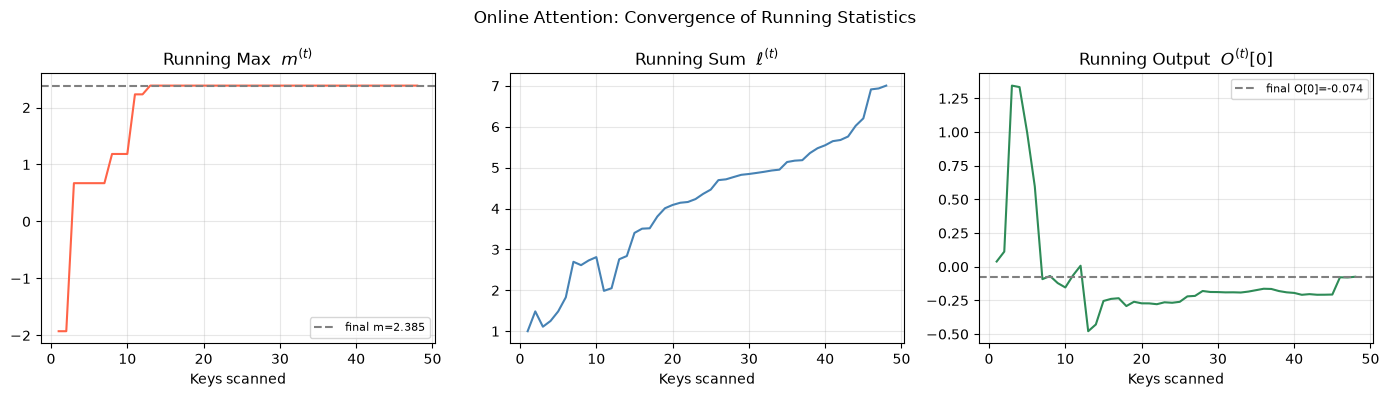

图像已保存至 results/02_online_convergence.png


In [36]:
d_vis, N_vis = 16, 48
q_v = torch.randn(d_vis)
K_v = torch.randn(N_vis, d_vis)
V_v = torch.randn(N_vis, d_vis)
scale_v = 1.0 / math.sqrt(d_vis)

# 追踪中间状态
m_history = []
l_history = []
o0_history = []  # 输出第 0 维

m = torch.tensor(float("-inf"), dtype=q_v.dtype)
l = torch.tensor(0.0, dtype=q_v.dtype)
O = torch.zeros(d_vis, dtype=q_v.dtype)

for j in range(N_vis):
    s_j = (q_v @ K_v[j]) * scale_v
    v_j = V_v[j]
    m_new = torch.maximum(m, s_j)
    l_new = torch.exp(m - m_new) * l + torch.exp(s_j - m_new)
    alpha = torch.exp(m - m_new) * l / l_new
    beta = torch.exp(s_j - m_new) / l_new
    O = alpha * O + beta * v_j
    m, l = m_new, l_new
    m_history.append(m.item())
    l_history.append(l.item())
    o0_history.append(O[0].item())

# 真实最终值（参考）
s_all = (q_v @ K_v.T) * scale_v
a_all = torch.softmax(s_all, dim=0)
o_final = (a_all @ V_v)[0].item()
m_final = s_all.max().item()

steps = list(range(1, N_vis + 1))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(steps, m_history, color="tomato")
axes[0].axhline(m_final, linestyle="--", color="gray", label=f"final m={m_final:.3f}")
axes[0].set_title("Running Max  $m^{(t)}$")
axes[0].set_xlabel("Keys scanned")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(steps, l_history, color="steelblue")
axes[1].set_title("Running Sum  $\\ell^{(t)}$")
axes[1].set_xlabel("Keys scanned")
axes[1].grid(alpha=0.3)

axes[2].plot(steps, o0_history, color="seagreen")
axes[2].axhline(o_final, linestyle="--", color="gray", label=f"final O[0]={o_final:.3f}")
axes[2].set_title("Running Output  $O^{(t)}[0]$")
axes[2].set_xlabel("Keys scanned")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle("Online Attention: Convergence of Running Statistics", fontsize=12)
plt.tight_layout()
plt.savefig("../results/02_online_convergence.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/02_online_convergence.png")

## 5 分块 Online Attention

上一节以**单个 key** 为步长扫描，实际场景中以**块**为单位读取更高效（GPU warp 对齐、向量化）。

将 $K$、$V$ 按行分成 $T_c$ 块（每块 $B_c$ 行），将 $Q$ 按行分成 $T_r$ 块（每块 $B_r$ 行）。对每个 $(Q$ 行块 $i$，$K/V$ 列块 $j)$ 组合，在**块**内部做矩阵乘，并用 Online 规则更新全局 $(m, \ell, O)$。

这就是 FlashAttention Algorithm 1里的，以 tiling 代替逐元素扫描，利用 GPU SRAM 容纳整块数据。

下面实现**批量+ 多头版本**，并与标准注意力对比结果。

In [37]:
def tiled_online_attention(
    Q: torch.Tensor,   # (B, H, N, d)
    K: torch.Tensor,   # (B, H, N, d)
    V: torch.Tensor,   # (B, H, N, d)
    block_r: int = 32,  # Q 块大小
    block_c: int = 32,  # K/V 块大小
    causal: bool = False,
) -> torch.Tensor:
    """
    Tiling Online Attention：FlashAttention Algorithm 1 的 PyTorch 模拟。

    形状：Q/K/V 均为 (B, H, N, d)，输出 (B, H, N, d)。
    """
    B, H, N, d = Q.shape
    scale = 1.0 / math.sqrt(d)

    Tr = math.ceil(N / block_r)
    Tc = math.ceil(N / block_c)

    O = torch.zeros_like(Q)               # (B,H,N,d)
    L = torch.zeros(B, H, N, device=Q.device, dtype=Q.dtype)   # 归一化分母
    M = torch.full((B, H, N), float("-inf"),
                   device=Q.device, dtype=Q.dtype)   # 行最大值

    for j in range(Tc):   # 外循环：K/V 列块
        jstart = j * block_c
        jend = min(jstart + block_c, N)
        Kj = K[:,:, jstart:jend,:]   # (B,H,Bc',d)
        Vj = V[:,:, jstart:jend,:]   # (B,H,Bc',d)

        for i in range(Tr):   # 内循环：Q 行块
            istart = i * block_r
            iend = min(istart + block_r, N)
            Qi = Q[:,:, istart:iend,:]   # (B,H,Br',d)

   # 局部 logits：(B, H, Br', Bc')
            Sij = torch.matmul(Qi, Kj.transpose(-2, -1)) * scale

   # 因果掩码
            if causal:
                q_pos = torch.arange(istart, iend, device=Q.device).unsqueeze(-1)  # (Br',1)
                k_pos = torch.arange(jstart, jend, device=Q.device).unsqueeze(0)   # (1,Bc')
                mask = (k_pos > q_pos).unsqueeze(0).unsqueeze(0)  # (1,1,Br',Bc')
                Sij = Sij.masked_fill(mask, float("-inf"))

   # 局部统计量
            m_tilde = Sij.max(dim=-1).values   # (B,H,Br')
            P_tilde = torch.exp(Sij - m_tilde.unsqueeze(-1))  # (B,H,Br',Bc')
            l_tilde = P_tilde.sum(dim=-1)   # (B,H,Br')

   # 读出旧的全局统计量
            mi = M[:,:, istart:iend]   # (B,H,Br')
            li = L[:,:, istart:iend]
            Oi = O[:,:, istart:iend,:]   # (B,H,Br',d)

   # 合并统计量
            mi_new = torch.maximum(mi, m_tilde)
            li_new = torch.exp(mi - mi_new) * li + torch.exp(m_tilde - mi_new) * l_tilde

   # 累积输出
            alpha = (torch.exp(mi - mi_new) * li / li_new).unsqueeze(-1)   # (B,H,Br',1)
            beta = (torch.exp(m_tilde - mi_new) / li_new).unsqueeze(-1)   # (B,H,Br',1)
            Oi_new = alpha * Oi + beta * torch.matmul(P_tilde, Vj)

   # 写回
            O[:,:, istart:iend,:] = Oi_new
            L[:,:, istart:iend] = li_new
            M[:,:, istart:iend] = mi_new

    return O

In [38]:
# ---- 正确性验证：非因果 ----
torch.manual_seed(42)
B, H, N, d = 2, 4, 128, 32

Q = torch.randn(B, H, N, d, device=device)
K = torch.randn(B, H, N, d, device=device)
V = torch.randn(B, H, N, d, device=device)

# 参考：PyTorch 内置 SDPA（math backend，精确等价标准注意力）
if device == "cuda":
    with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False):
        ref = F.scaled_dot_product_attention(Q, K, V)
else:
    ref = F.scaled_dot_product_attention(Q, K, V)

print("=== 非因果注意力 ===")
print(f"{'块大小':>8}  {'最大绝对误差':>10}  通过")
print("-"* 42)
for bs in [8, 16, 32, 64, 128]:
    out = tiled_online_attention(Q, K, V, block_r=bs, block_c=bs)
    err = (out - ref).abs().max().item()
    ok = "✓"if err < 1e-4 else "✗"
    print(f"{bs:>8}  {err:>15.2e}  {ok}")

print("\n=== 因果注意力 ===")
if device == "cuda":
    with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_math=True, enable_mem_efficient=False):
        ref_c = F.scaled_dot_product_attention(Q, K, V, is_causal=True)
else:
    ref_c = F.scaled_dot_product_attention(Q, K, V, is_causal=True)

for bs in [8, 32, 64]:
    out_c = tiled_online_attention(Q, K, V, block_r=bs, block_c=bs, causal=True)
    err_c = (out_c - ref_c).abs().max().item()
    ok_c = "✓"if err_c < 1e-4 else "✗"
    print(f"{bs:>8}  {err:>15.2e}  {ok}")


=== 非因果注意力 ===
     块大小      最大绝对误差  通过
------------------------------------------
       8         6.56e-07  ✓
      16         7.15e-07  ✓
      32         9.54e-07  ✓
      64         1.01e-06  ✓
     128         1.25e-06  ✓

=== 因果注意力 ===
       8         1.25e-06  ✓
      32         1.25e-06  ✓
      64         1.25e-06  ✓


## 6 数值精度分析

Online Softmax 引入了额外的乘法修正项（$e^{m_\text{old} - m_\text{new}}$），理论上不损失精度，但、会不会因为“分块大小不同”以及“使用 FP32/FP16”而产生不同程度的数值误差？

于是，本节分析：
1. 块大小对精度的影响
2. FP16 vs FP32 的精度差异

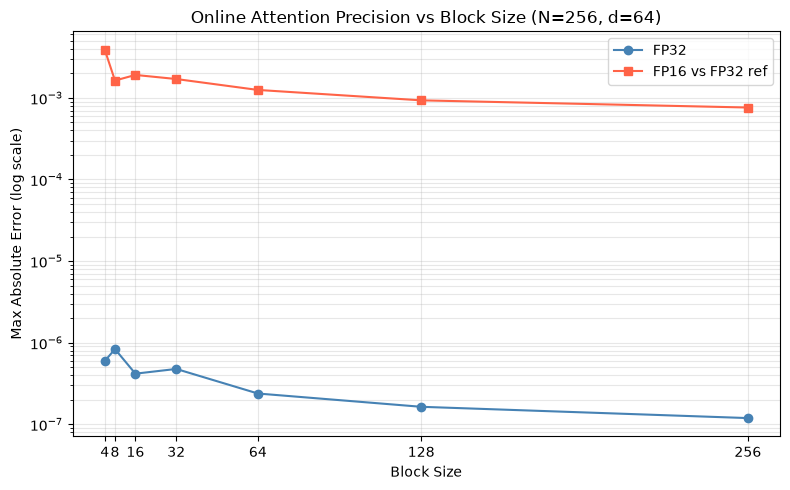

图像已保存至 results/02_precision_vs_blocksize.png


In [47]:
torch.manual_seed(0)
B2, H2, N2, d2 = 1, 1, 256, 64

Q2 = torch.randn(B2, H2, N2, d2)
K2 = torch.randn(B2, H2, N2, d2)
V2 = torch.randn(B2, H2, N2, d2)

# FP32 参考
ref_fp32 = F.scaled_dot_product_attention(Q2, K2, V2)

block_sizes = [4, 8, 16, 32, 64, 128, 256]
errors_fp32 = []
errors_fp16 = []

for bs in block_sizes:
   # FP32
    out32 = tiled_online_attention(Q2, K2, V2, block_r=bs, block_c=bs)
    errors_fp32.append((out32 - ref_fp32).abs().max().item())

   # FP16
    Q2h = Q2.half()
    K2h = K2.half()
    V2h = V2.half()
    out16 = tiled_online_attention(Q2h, K2h, V2h, block_r=bs, block_c=bs)
    errors_fp16.append((out16.float() - ref_fp32).abs().max().item())


fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(block_sizes, errors_fp32, marker="o", color="steelblue", label="FP32")
if not all(math.isnan(e) for e in errors_fp16):
    ax.semilogy(block_sizes, errors_fp16, marker="s", color="tomato", label="FP16 vs FP32 ref")

ax.set_xlabel("Block Size")
ax.set_ylabel("Max Absolute Error (log scale)")
ax.set_title(f"Online Attention Precision vs Block Size (N={N2}, d={d2})")
ax.set_xticks(block_sizes)
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("../results/02_precision_vs_blocksize.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/02_precision_vs_blocksize.png")

实验结果表明，FP32 下的 Tiled Online Attention 与 PyTorch 参考实现高度一致，最大绝对误差约为 $10^{-7}$ 数量级。不同 block size 会改变浮点运算顺序，因此误差会有轻微波动。相比之下，FP16 的误差约为 $10^{-3}$ 数量级，说明降低数值精度会显著增加浮点误差。

## 7 性能对比

将 `tiled_online_attention` 与标准注意力（baseline）和 PyTorch SDPA 对比。

- standard (math): 标准 Attention baseline

- tiled_online: 验证本实验的 tiling + online softmax

- F.sdpa (default): PyTorch 高性能实现，自动选择

In [ ]:
import torch.utils.benchmark as benchmark


def measure(fn, *args, n_warmup=3, n_repeat=10, label=""):
    dev = args[0].device
    for _ in range(n_warmup):
        fn(*args)
    if dev.type == "cuda":
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        fn(*args)
        torch.cuda.synchronize()
        mem_mb = torch.cuda.max_memory_allocated() / 1e6
    else:
        mem_mb = float("nan")
    t = benchmark.Timer(
        stmt="fn(*args)",
        globals={"fn": fn, "args": args},
        label=label,
        num_threads=1,
    )
    r = t.timeit(n_repeat)
    return {
        "label": label,
        "latency_ms": r.mean * 1e3,
        "memory_mb": mem_mb,
        "seq_len": args[0].shape[-2],
        "impl": label,
    }


def run_standard(Q, K, V):
    """标准注意力（用 F.sdpa 的math backend）"""
    if Q.device.type == "cuda":
        with torch.backends.cuda.sdp_kernel(
            enable_flash=False, enable_math=True, enable_mem_efficient=False
        ):
            return F.scaled_dot_product_attention(Q, K, V)
    return F.scaled_dot_product_attention(Q, K, V)


def run_tiled(Q, K, V):
    return tiled_online_attention(Q, K, V, block_r=32, block_c=32)


def run_sdpa_default(Q, K, V):
    """PyTorch 默认 SDPA（GPU 上自动选一个 backend）"""
    return F.scaled_dot_product_attention(Q, K, V)


SEQ_LENS = [128, 256, 512]
if device == "cuda":
    SEQ_LENS += [1024]
D_K, HEADS, BATCH = 64, 4, 1

records = []
impls = [
    ("standard (math)", run_standard),
    ("tiled_online",    run_tiled),
    ("F.sdpa (default)", run_sdpa_default),
]

print(f"{'N':>5}  {'实现':>18}  {'延迟(ms)':>10}  {'显存(MB)':>10}")
print("-"* 52)

for N3 in SEQ_LENS:
    torch.manual_seed(0)
    Qb = torch.randn(BATCH, HEADS, N3, D_K, device=device)
    Kb = torch.randn(BATCH, HEADS, N3, D_K, device=device)
    Vb = torch.randn(BATCH, HEADS, N3, D_K, device=device)

    for name, fn in impls:
        try:
            rec = measure(fn, Qb, Kb, Vb, label=name)
            records.append(rec)
            print(f"{N3:>5}  {name:>18}  {rec['latency_ms']:>10.3f}  {rec['memory_mb']:>10.1f}")
        except Exception as e:
            print(f"{N3:>5}  {name:>18}  ERROR: {e}")

with open("../results/02_benchmark_online_softmax.json", "w") as f:
    json.dump(records, f, indent=2)
print("\n结果已保存至 results/02_benchmark_online_softmax.json")

    N                  实现      延迟(ms)      显存(MB)
----------------------------------------------------
  128     standard (math)       0.444        10.6
  128        tiled_online      13.771        10.1
  128    F.sdpa (default)       0.148        10.0
  256     standard (math)       0.401        12.8
  256        tiled_online      48.078        10.7
  256    F.sdpa (default)       0.151        10.5
  512     standard (math)       0.421        21.0
  512        tiled_online     190.234        11.7
  512    F.sdpa (default)       0.331        11.5
 1024     standard (math)       5.917        51.4
 1024        tiled_online     740.420        13.8
 1024    F.sdpa (default)       0.906        13.6

结果已保存至 results/02_benchmark_online_softmax.json


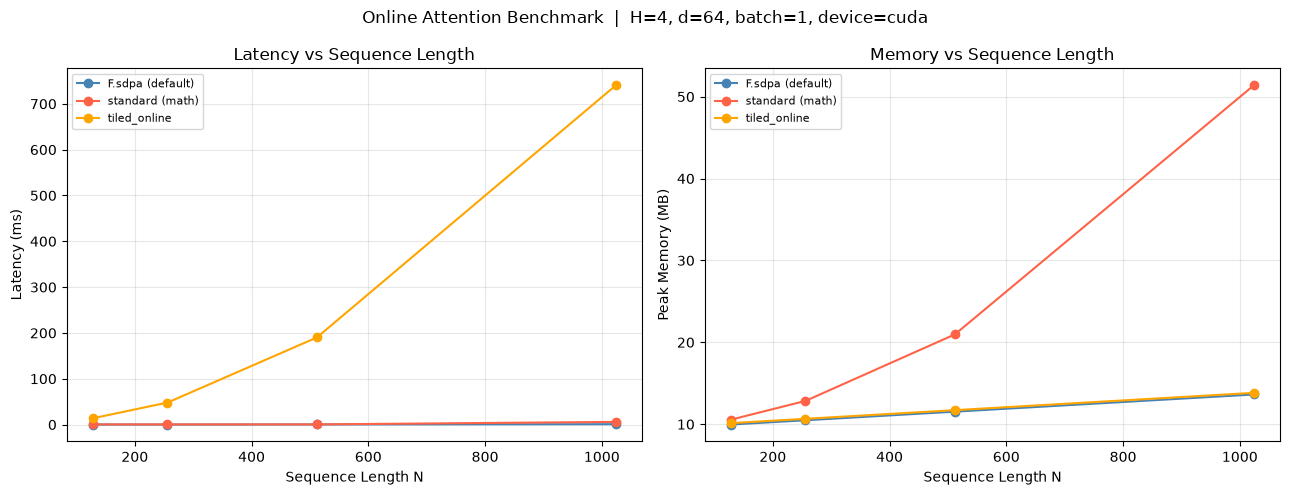

图像已保存至 results/02_benchmark_plot.png


In [41]:
import pandas as pd

df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"standard (math)": "tomato", "tiled_online": "orange", "F.sdpa (default)": "steelblue"}

for ax, metric, ylabel, title in [
    (axes[0], "latency_ms", "Latency (ms)",    "Latency vs Sequence Length"),
    (axes[1], "memory_mb",  "Peak Memory (MB)", "Memory vs Sequence Length"),
]:
    for impl, grp in df.groupby("impl"):
        g = grp.sort_values("seq_len")
        valid = g.dropna(subset=[metric])
        if valid.empty:
            continue
        ax.plot(valid["seq_len"], valid[metric],
                marker="o", label=impl, color=colors.get(impl))
    ax.set_xlabel("Sequence Length N")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f"Online Attention Benchmark  |  H={HEADS}, d={D_K}, batch={BATCH}, device={device}")
plt.tight_layout()
plt.savefig("../results/02_benchmark_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/02_benchmark_plot.png")

由图可知，Python 层面的 tiled + online softmax 实现通过避免显式存储完整的 $N\times N$ Attention 矩阵，显著降低了显存增长；但由于 Python 循环和大量小规模 GPU 操作，其延迟反而很高。PyTorch 默认的 SDPA 则通过高度优化的 fused GPU kernel，同时实现了较低的显存占用和较低的延迟。

## 8 小结与展望

### 本节要点汇总

| 概念 | 核心内容 |
|------|----------|
| **Safe Softmax** | 减去行最大值 $m$ 防止溢出；数学上等价于原始 softmax |
| **Online Softmax** | 维护 $(m^{(t)}, \ell^{(t)})$ 两个累积量，**一趟扫描**得到正确 softmax |
| **更新规则** | $m^{(t+1)} = \max(m^{(t)}, x_{t+1})$；$\ell^{(t+1)} = e^{m^{(t)}-m^{(t+1)}} \ell^{(t)} + e^{x_{t+1}-m^{(t+1)}}$ |
| **输出累积** | 同步维护 $O^{(t)}$，每步用修正系数 $\alpha, \beta$ 更新，避免额外遍历 |
| **可结合性** | $(m, \ell)$ 的合并满足结合律，支持树状归约和多路并行 |
| **Tiling 版本** | 以块（而非逐元素）为单位更新，与 FlashAttention Algorithm 1 完全对应 |
| **精度** | FP32 下误差在 $10^{-6}$ 量级；块大小不剧烈影响精度 |

### 与 FlashAttention 的关系

```
Online Softmax
    ↓  嵌入 Tiling 框架
FlashAttention Algorithm 1（前向）
    ↓  加入 IO 复杂度分析 + CUDA kernel
真正的 IO 高效精确注意力
```

Online Softmax 解决的是**算法层面**的问题（如何在不保存完整 $A$ 矩阵的前提下得到正确输出），FlashAttention 在此基础上进一步解决**硬件层面**的问题（如何将块装入 SRAM，最小化 HBM 访问）。
---
*参考文献*
- Dao et al. "FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness", NeurIPS 2022.
- Milakov & Gimelshein. "Online normalizer calculation for softmax", arXiv:1805.02867, 2018.
- Rabe & Staats. "Self-attention Does Not Need $O(n^2)$ Memory", arXiv:2112.05682, 2021.